## 初级要求

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, make_moons, make_blobs, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)


In [9]:
def pairwise_dist(X):
    """计算欧氏距离矩阵，对角置为 inf 便于寻找最近簇"""
    sq = np.sum(X**2, axis=1, keepdims=True)
    d2 = sq + sq.T - 2 * X @ X.T
    d2[d2 < 0] = 0  # 数值稳定
    D = np.sqrt(d2)
    np.fill_diagonal(D, np.inf)
    return D

def linkage_distance(D, clusters, i, j, method):
    """给定当前簇索引列表 clusters，计算 i, j 簇间距离"""
    sub = D[np.ix_(clusters[i], clusters[j])]
    if method == "single":
        return np.min(sub)
    if method == "complete":
        return np.max(sub)
    if method == "average":
        return np.mean(sub)
    raise ValueError("unknown linkage")

def hierarchical_clustering(X, k=3, method="single"):
    """朴素 O(n^3) 层次聚类，返回标签与合并历史"""
    D = pairwise_dist(X)
    clusters = [[i] for i in range(len(X))]
    merge_history = []

    while len(clusters) > k:
        m = len(clusters)
        best = (np.inf, None, None)
        for i in range(m):
            for j in range(i + 1, m):
                d = linkage_distance(D, clusters, i, j, method)
                if d < best[0]:
                    best = (d, i, j)
        d, a, b = best
        new_cluster = clusters[a] + clusters[b]
        for idx in sorted([a, b], reverse=True):
            clusters.pop(idx)
        clusters.append(new_cluster)
        merge_history.append((a, b, d, len(new_cluster)))

    labels = np.empty(len(X), dtype=int)
    for cid, idxs in enumerate(clusters):
        labels[idxs] = cid
    return labels, merge_history

In [10]:
def scatter_2d(X2, labels, title):
    palette = sns.color_palette("tab10", np.unique(labels).size)
    plt.figure()
    for c in np.unique(labels):
        idx = labels == c
        plt.scatter(X2[idx, 0], X2[idx, 1], s=30, color=palette[c], label=f"cluster {c}", alpha=0.8)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

def eval_scores(X, labels, y_true=None, name=""):
    sil = silhouette_score(X, labels)
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
    print(f"[{name}] silhouette={sil:.3f}" + (f", ARI={ari:.3f}" if y_true is not None else ""))

def run_and_plot(X, X2, method, k, y_true=None, prefix="Wine"):
    labels, _ = hierarchical_clustering(X, k=k, method=method)
    eval_scores(X, labels, y_true, name=f"{prefix}-{method}")
    scatter_2d(X2, labels, f"{prefix}: {method}-linkage (k={k})")
    return labels

In [11]:
wine = load_wine()#这里直接从sklearn中加载的数据集和助教提供的是一样的
X_raw = wine.data
y_true = wine.target
feature_names = wine.feature_names

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

print("Wine 数据形状:", X.shape)

Wine 数据形状: (178, 13)


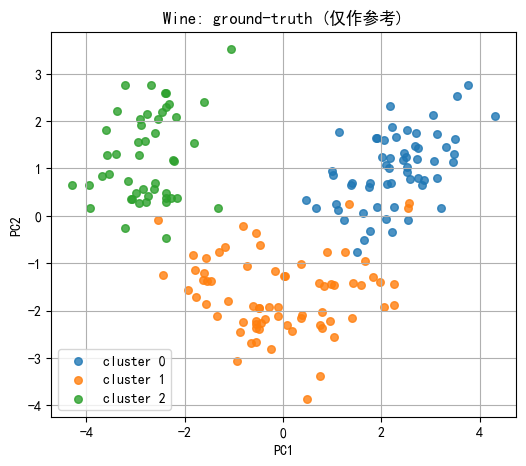

In [ ]:
scatter_2d(X2, y_true, "Wine: ground-truth")

## 初级要求：single / complete

[Wine-single] silhouette=0.183, ARI=-0.007


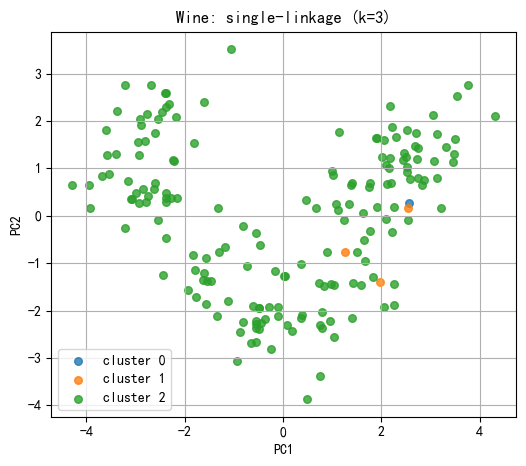

[Wine-complete] silhouette=0.204, ARI=0.577


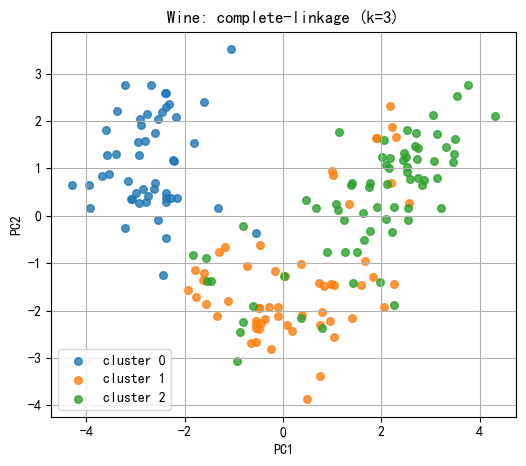

In [13]:
k = 3  # Wine 共有 3 类
labels_single = run_and_plot(X, X2, method="single", k=k, y_true=y_true, prefix="Wine")
labels_complete = run_and_plot(X, X2, method="complete", k=k, y_true=y_true, prefix="Wine")

## 中级要求：average

[Wine-average] silhouette=0.158, ARI=-0.005


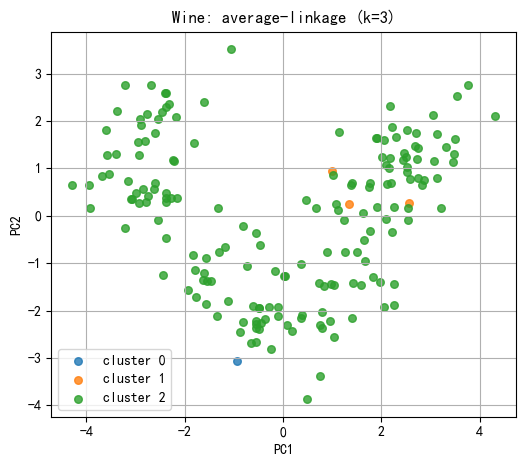

In [14]:
labels_average = run_and_plot(X, X2, method="average", k=3, y_true=y_true,prefix="Wine")

## 高级要求：额外数据集对比


=== 数据集: moons ===


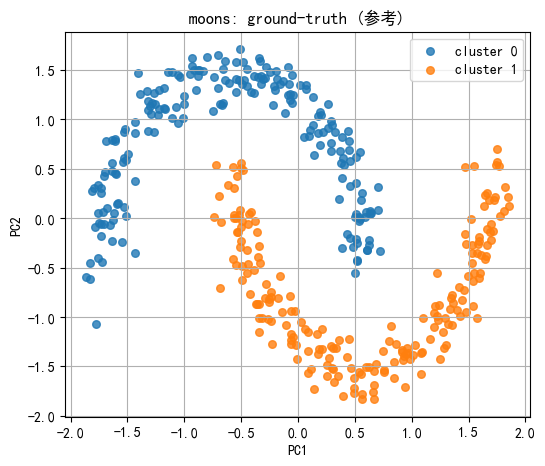

[moons-single] silhouette=0.374, ARI=1.000


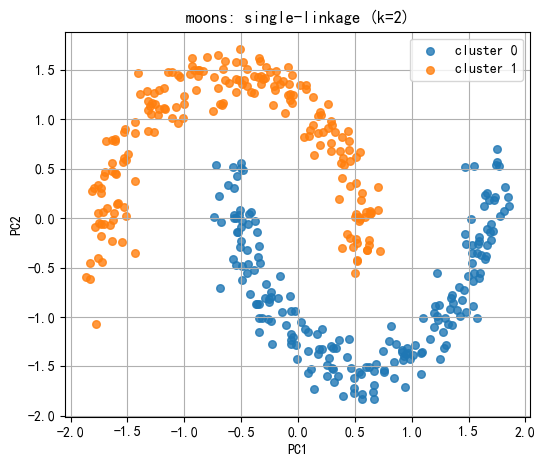

[moons-complete] silhouette=0.490, ARI=0.482


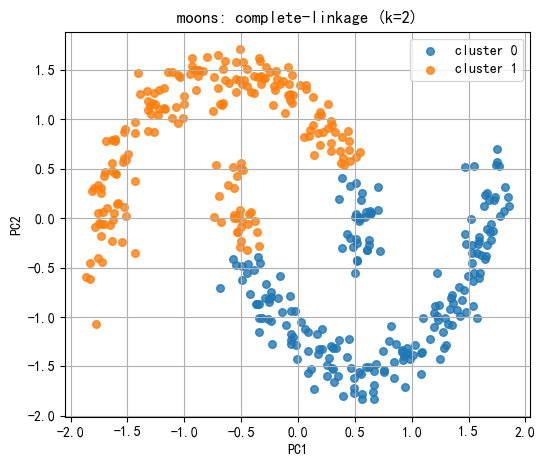

[moons-average] silhouette=0.446, ARI=0.647


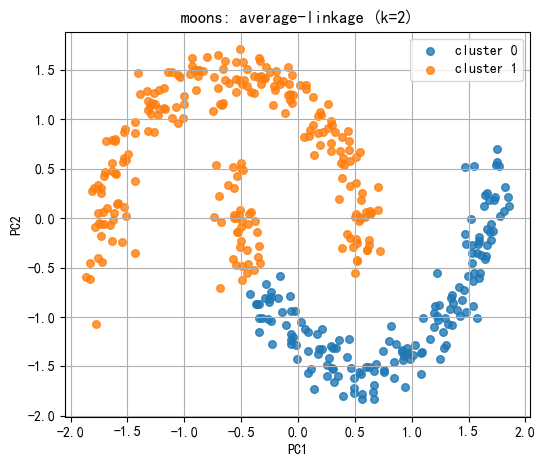


=== 数据集: blobs ===


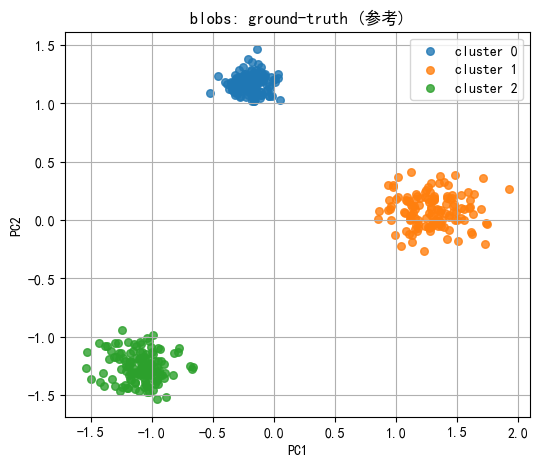

[blobs-single] silhouette=0.883, ARI=1.000


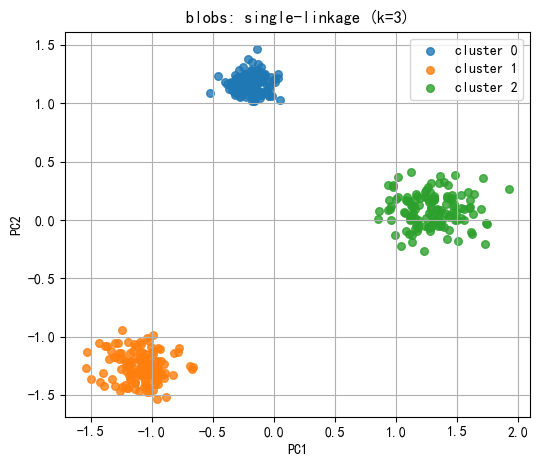

[blobs-complete] silhouette=0.883, ARI=1.000


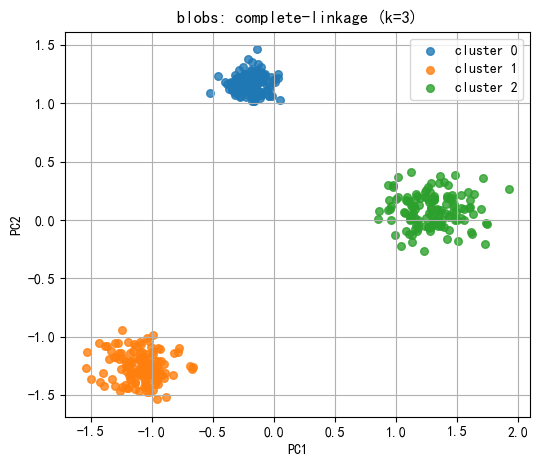

[blobs-average] silhouette=0.883, ARI=1.000


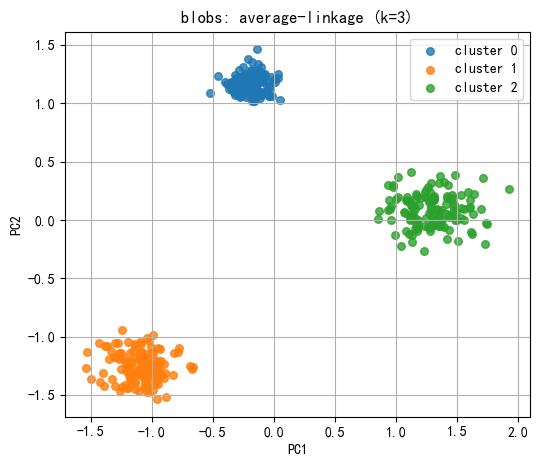


=== 数据集: anisotropic ===


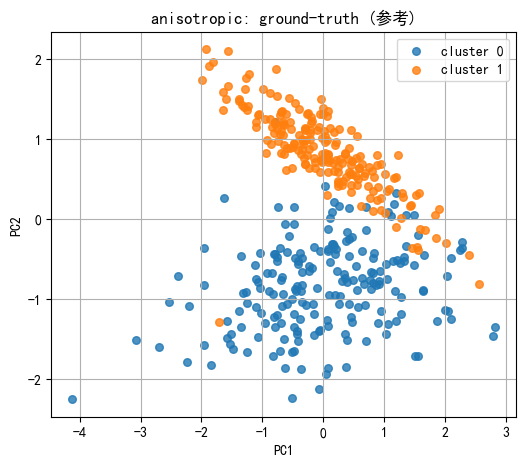

[anisotropic-single] silhouette=0.611, ARI=0.000


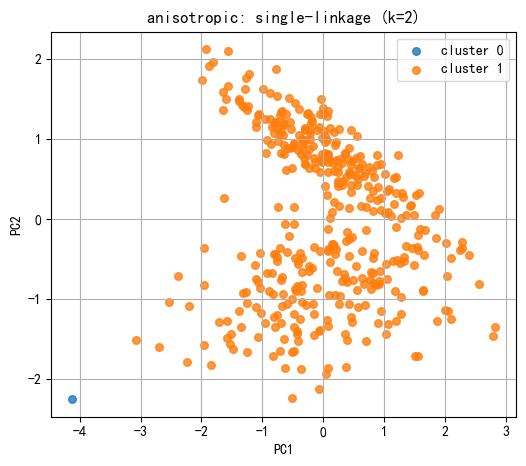

[anisotropic-complete] silhouette=0.307, ARI=0.138


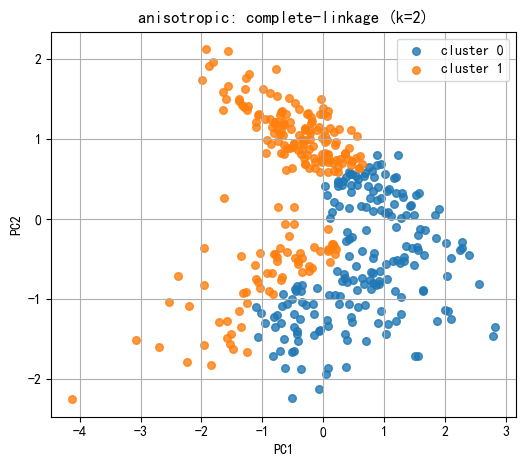

[anisotropic-average] silhouette=0.526, ARI=0.000


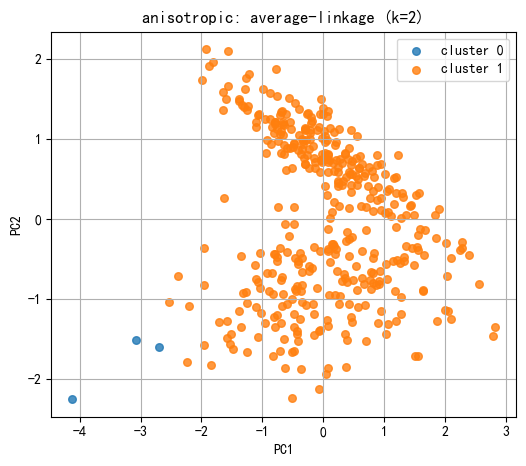

In [15]:
def make_and_eval(dataset_name):
    if dataset_name == "moons":
        X_raw, y = make_moons(n_samples=400, noise=0.08, random_state=42)
    elif dataset_name == "blobs":
        X_raw, y = make_blobs(n_samples=400, centers=3, cluster_std=[0.5, 1.0, 0.8], random_state=42)
    elif dataset_name == "anisotropic":
        X_raw, y = make_classification(
            n_samples=400, n_features=2, n_informative=2, n_redundant=0,
            n_clusters_per_class=1, class_sep=1.5, flip_y=0.02, random_state=42
        )
    else:
        raise ValueError("unknown dataset")

    X = StandardScaler().fit_transform(X_raw)
    X2 = X  # 2D 已足够展示
    print(f"\n=== 数据集: {dataset_name} ===")
    scatter_2d(X2, y, f"{dataset_name}: ground-truth (参考)")

    for method in ["single", "complete", "average"]:
        run_and_plot(X, X2, method=method, k=len(np.unique(y)), y_true=y, prefix=dataset_name)

for name in ["moons", "blobs", "anisotropic"]:
    make_and_eval(name)

In [16]:
import time
import random
import numpy as np

In [17]:
class DSUPlain:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        while self.parent[x] != x:
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        self.parent[rb] = ra
        return True

class DSUOptimized:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n  # 也可改为 size
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # 路径压缩
        return self.parent[x]
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True

In [18]:
def kruskal_mst(n, edges, dsu_cls):
    # edges: list of (w, u, v)
    edges_sorted = sorted(edges, key=lambda x: x[0])
    dsu = dsu_cls(n)
    mst_w = 0
    used = 0
    for w, u, v in edges_sorted:
        if dsu.union(u, v):
            mst_w += w
            used += 1
            if used == n - 1:
                break
    return mst_w

In [19]:
def gen_random_graph(n, m, wlow=1, whigh=100):
    edges = set()
    while len(edges) < m:
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        if u > v:
            u, v = v, u
        if (u, v) not in edges:
            w = random.randint(wlow, whigh)
            edges.add((u, v, w))
    return [(w, u, v) for (u, v, w) in edges]

def bench(n=5000, density=4):
    # density 约等于平均度，m ≈ n * density / 2
    m = n * density // 2
    edges = gen_random_graph(n, m)
    for name, dsu_cls in [("plain", DSUPlain), ("optimized", DSUOptimized)]:
        t0 = time.perf_counter()
        w = kruskal_mst(n, edges, dsu_cls)
        t1 = time.perf_counter()
        print(f"{name:10s} n={n}, m={m}, mst_w={w}, time={t1 - t0:.4f}s")
        
bench(n=4000, density=6)

plain      n=4000, m=12000, mst_w=77696, time=0.7353s
optimized  n=4000, m=12000, mst_w=77696, time=0.0167s


In [20]:
for n in [2000, 4000, 8000]:
    for density in [4, 8, 16]:
        print(f"\n==== n={n}, density={density} ====")
        bench(n=n, density=density)


==== n=2000, density=4 ====
plain      n=2000, m=4000, mst_w=58549, time=0.0830s
optimized  n=2000, m=4000, mst_w=58549, time=0.0050s

==== n=2000, density=8 ====
plain      n=2000, m=8000, mst_w=29934, time=0.2772s
optimized  n=2000, m=8000, mst_w=29934, time=0.0165s

==== n=2000, density=16 ====
plain      n=2000, m=16000, mst_w=15882, time=0.2731s
optimized  n=2000, m=16000, mst_w=15882, time=0.0123s

==== n=4000, density=4 ====
plain      n=4000, m=8000, mst_w=112980, time=0.3717s
optimized  n=4000, m=8000, mst_w=112980, time=0.0130s

==== n=4000, density=8 ====
plain      n=4000, m=16000, mst_w=62138, time=1.0922s
optimized  n=4000, m=16000, mst_w=62138, time=0.0225s

==== n=4000, density=16 ====
plain      n=4000, m=32000, mst_w=32167, time=1.4635s
optimized  n=4000, m=32000, mst_w=32167, time=0.0442s

==== n=8000, density=4 ====
plain      n=8000, m=16000, mst_w=227877, time=1.3419s
optimized  n=8000, m=16000, mst_w=227877, time=0.0420s

==== n=8000, density=8 ====
plain      n